In [69]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

output_path = Path('.').parent / '../output'  
csv_file_path_racing_line = output_path / 'racing_line_coordinates.csv'


In [70]:
import pandas as pd
# Load the racing line coordinates from the CSV file
racing_line_df = pd.read_csv(csv_file_path_racing_line)
racing_line_df

,x_world,y_world
0,0.560000,0.160000
1,0.284729,0.110000
2,0.009617,0.059617
3,-0.228963,0.021037
4,-0.499663,-0.040000
...,...,...
95,1.773216,0.110000
96,1.497945,0.160000
97,1.201963,0.160000
98,0.905982,0.160000


In [71]:
racing_track = racing_line_df.to_numpy()
racing_track

array([[ 0.56      ,  0.16      ],
       [ 0.284729  ,  0.11      ],
       [ 0.00961675,  0.05961675],
       [-0.22896323,  0.02103677],
       [-0.49966264, -0.04      ],
       [-0.76470182, -0.11470182],
       [-1.02949397, -0.19      ],
       [-1.28405429, -0.29      ],
       [-1.52437572, -0.42437572],
       [-1.77246425, -0.54      ],
       [-2.0063139 , -0.69      ],
       [-2.24011564, -0.84011564],
       [-2.44940629, -1.04940629],
       [-2.65869694, -1.25869694],
       [-2.83263226, -1.48263226],
       [-2.97121223, -1.72121223],
       [-3.07443686, -1.97443686],
       [-3.14      , -2.2432614 ],
       [-3.19      , -2.5185324 ],
       [-3.19      , -2.81451408],
       [-3.24      , -3.08978508],
       [-3.19      , -3.36505608],
       [-3.14      , -3.64032708],
       [-3.09      , -3.91559808],
       [-2.99      , -4.1701584 ],
       [-2.86545015, -4.41454985],
       [-2.69151484, -4.63848516],
       [-2.51757953, -4.86242047],
       [-2.30828888,

In [72]:
# Uses previous and next coords to calculate the radius of the curve
# so you need to pass a list with form [[x1,y1],[x2,y2],[x3,y3]]
# Input 3 coords [[x1,y1],[x2,y2],[x3,y3]]
from typing import Dict, List

def wrapping_rolling_average(data_list: List[float], window_size: int) -> List[float]:
    """
    Calculates a rolling average on a list of data that wraps around,
    like on a racetrack.
    
    Args:
        data_list: The list of numbers to smooth (e.g., your radii).
        window_size: The number of points to include in the average. Must be odd.

    Returns:
        A new list containing the smoothed data.
    """
    if not window_size % 2:
        raise ValueError("Window size must be an odd number.")
    if len(data_list) < window_size:
        # Not enough data to smooth, return the original list
        return data_list
        
    # Convert to a pandas Series and handle any lingering infs/nans
    # Your combined interpolation is fine here.
    data_series = pd.Series(data_list).replace(np.inf, np.nan).interpolate(method='linear')
    # Fill any remaining NaNs at the start/end after interpolation
    data_series.bfill(inplace=True)
    data_series.ffill(inplace=True)
    
    # Create a temporary, extended series to handle the wrap-around
    half_window = window_size // 2
    wrapped_data = pd.concat([
        data_series.iloc[-half_window:], 
        data_series, 
        data_series.iloc[:half_window]
    ])
    
    # Calculate the rolling average on the wrapped data using a CENTERED window
    rolling_mean = wrapped_data.rolling(window=window_size, center=True).mean()
    
    # Extract the valid, smoothed data which corresponds to the original series length
    # This slice now correctly aligns with the output of the centered rolling mean.
    smoothed_list = rolling_mean.iloc[half_window:-half_window].tolist()
    
    return smoothed_list

def circle_radius(coords: List[List[float]]) -> float:

    # Flatten the list and assign to variables (makes code easier to read later)
    x1, y1, x2, y2, x3, y3 = [i for sub in coords for i in sub]

    a = x1*(y2-y3) - y1*(x2-x3) + x2*y3 - x3*y2
    b = (x1**2+y1**2)*(y3-y2) + (x2**2+y2**2)*(y1-y3) + (x3**2+y3**2)*(y2-y1)
    c = (x1**2+y1**2)*(x2-x3) + (x2**2+y2**2)*(x3-x1) + (x3**2+y3**2)*(x1-x2)
    d = (x1**2+y1**2)*(x3*y2-x2*y3) + (x2**2+y2**2) * \
        (x1*y3-x3*y1) + (x3**2+y3**2)*(x2*y1-x1*y2)

    # In case a is zero (so radius is infinity)
    try:
        r = abs((b**2+c**2-4*a*d) / abs(4*a**2)) ** 0.5
    except:
        r = 999

    return r


# Returns indexes of next index and index+lookfront
# We need this to calculate the radius for next track section.
def circle_indexes(mylist, index_car, add_index_1=0, add_index_2=0):

    list_len = len(mylist)

    # Use modulo to consider that track is cyclical
    index_1 = (index_car + add_index_1) % list_len
    index_2 = (index_car + add_index_2) % list_len

    return [index_car, index_1, index_2]


def optimal_velocity(
    track: list, 
    speed_map: Dict[float, float],  
    min_speed: float, 
    max_speed: float, 
    look_ahead_points: int, 
    smoothing_window_size: int, 
    roll: int,
    max_acceleration: float,
    max_deceleration: float
) -> list:
    """
    Calculates a drivable velocity profile using the provided inputs,
    upgrading the internal logic for physical accuracy and stability.
    """
    track_len = len(track)

    # --- Step 1: Calculate and Smooth Radii ---
    raw_radii = []
    for i in range(track_len):
        # Using a wider, more stable spacing for radius calculation
        p_prev = track[(i - 5 + track_len) % track_len]
        p_curr = track[i]
        p_next = track[(i + 5) % track_len]
        raw_radii.append(circle_radius([p_prev, p_curr, p_next]))
    
    # Interpolate inf values caused by straight lines
    s = pd.Series(raw_radii).replace(np.inf, np.nan)
    if s.count() >= 2: # Need at least two points to interpolate
        s_wrapped = pd.concat([s, s, s]).interpolate(method='linear')
        radii_interpolated = s_wrapped.iloc[track_len : 2 * track_len].tolist()
    else: # Fallback for tracks with few corners
        radii_interpolated = s.fillna(9999.0).tolist()
    
    # Smooth the final radius profile
    smoothed_radii = wrapping_rolling_average(radii_interpolated, window_size=smoothing_window_size)
    
        
    # --- Step 2: Calculate Target Velocity from the Custom Speed Map ---
    # This is the flexible mapping function.
    map_radii = sorted(speed_map.keys())
    map_speeds = [speed_map[r] for r in map_radii]
    
    target_velocity = []
    for r in smoothed_radii:
        # np.interp finds the correct speed for any radius 'r' based on our map
        v_target = np.interp(r, map_radii, map_speeds)
        target_velocity.append(min(v_target, max_speed))

    # --- Step 3: Apply Physics Constraints with the Two-Pass Model ---
    final_velocity = target_velocity.copy()

    if look_ahead_points == 0:
        # NO LOOKAHEAD: A single forward pass for acceleration constraints.
        # This models a purely reactive driver.
        print("INFO: look_ahead_points = 0. Running a forward pass (acceleration only).")
        for i in range(track_len - 1):
            distance = np.linalg.norm(np.array(track[i+1]) - np.array(track[i]))
            if distance <= 0: continue
            
            v_max_accel = (final_velocity[i]**2 + 2 * max_acceleration * distance)**0.5
            final_velocity[i+1] = min(final_velocity[i+1], v_max_accel)
        
        # NOTE: The 'roll' parameter is a manual fix for a lack of lookahead.
        # It is applied here as requested, but is not needed with the two-pass model.
        if roll:
            final_velocity = final_velocity[-roll:] + final_velocity[:-roll]

    else:
        # LOOKAHEAD > 0: The full Two-Pass Model is the correct implementation of "lookahead".
        # It anticipates all corners perfectly. The 'roll' parameter is ignored.
        print(f"INFO: look_ahead_points > 0. Running Two-Pass Model (braking and acceleration).")
        if roll:
            print("INFO: 'roll' parameter is ignored when look_ahead_points > 0, as the Two-Pass model handles timing automatically.")

        # PASS 1: BACKWARD (Braking constraints - The "Lookahead")
        for _ in range(2 * track_len):
            i = (track_len - 1 - _) % track_len
            i_next = (i + 1) % track_len
            distance = np.linalg.norm(np.array(track[i]) - np.array(track[i_next]))
            if distance <= 0: continue
            v_max_braking = (final_velocity[i_next]**2 + 2 * max_deceleration * distance)**0.5
            final_velocity[i] = min(final_velocity[i], v_max_braking)

        # PASS 2: FORWARD (Acceleration constraints)
        for _ in range(2 * track_len):
            i = _ % track_len
            i_prev = (i - 1 + track_len) % track_len
            distance = np.linalg.norm(np.array(track[i]) - np.array(track[i_prev]))
            if distance <= 0: continue
            v_max_accel = (final_velocity[i_prev]**2 + 2 * max_acceleration * distance)**0.5
            final_velocity[i] = min(final_velocity[i], v_max_accel)
            
    return final_velocity
# For each point in racing track, check if left curve (returns boolean)
def is_left_curve(coords: List[List[float]]) -> bool:

    # Flatten the list and assign to variables (makes code easier to read later)
    x1, y1, x2, y2, x3, y3 = [i for sub in coords for i in sub]

    return ((x2-x1)*(y3-y1) - (y2-y1)*(x3-x1)) > 0


# Calculate the distance between 2 points
def dist_2_points(x1: float, x2: float, y1: float, y2: float) -> float:
        return abs(abs(x1-x2)**2 + abs(y1-y2)**2)**0.5


# Calculate optimal speed


Change LOOK_AHEAD_POINTS to influence how many points the algorithm looks ahead (the higher, the sooner the car will start to break)
Change MIN_SPEED and MAX_SPEED to fit the track and model !


INFO: look_ahead_points = 0. Running a forward pass (acceleration only).


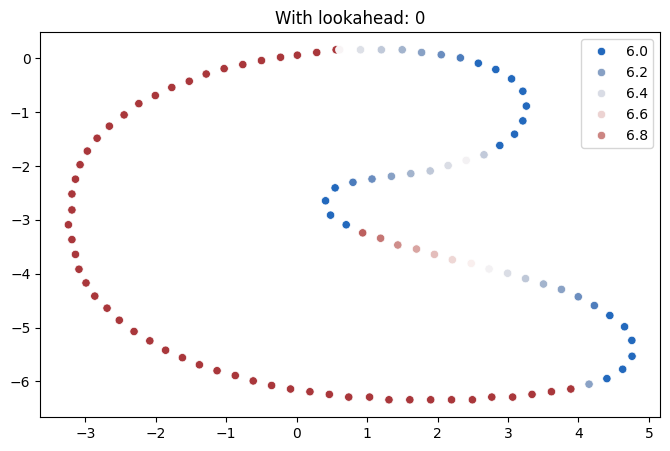

In [85]:
from matplotlib import pyplot as plt
import seaborn as sns

LOOK_AHEAD_POINTS = 0
ROLL_SIZE = 0
SMOOTHING_WINDOW_SIZE = 7
MIN_SPEED = 1.0
MAX_SPEED = 7
MAX_ACC = 1.5  # Maximal acceleration
MAX_DEC = 1.5  # Maximal deceleration

my_car_personality = {
    2.5: 7,    # At a xm radius, target speed is y m/s
    2: 6,   # At a 2m radius, target speed is 6 m/s
}

# Calculate optimal speed
velocity = optimal_velocity(
    track=racing_track, 
    speed_map=my_car_personality,
    min_speed=MIN_SPEED, 
    max_speed=MAX_SPEED, 
    look_ahead_points=LOOK_AHEAD_POINTS, 
    smoothing_window_size=SMOOTHING_WINDOW_SIZE, 
    roll=ROLL_SIZE,
    max_acceleration=MAX_ACC,
    max_deceleration=MAX_DEC
)

x = [i[0] for i in racing_track]
y = [i[1] for i in racing_track]
fig, ax = plt.subplots(figsize=(8, 5))
ax = sns.scatterplot(x=x, y=y, hue=velocity, palette="vlag").set_title(
    f"With lookahead: {LOOK_AHEAD_POINTS}")




In [86]:

from matplotlib import pyplot as plt
import seaborn as sns


# Without lookahead
velocity_no_lookahead = optimal_velocity(
    track=racing_track,
    speed_map=my_car_personality,
    min_speed=MIN_SPEED, 
    max_speed=MAX_SPEED, 
    look_ahead_points=0, 
    smoothing_window_size=SMOOTHING_WINDOW_SIZE, 
    roll=ROLL_SIZE,
    max_acceleration=MAX_ACC,
    max_deceleration=MAX_DEC
)
velocity_no_lookahead

INFO: look_ahead_points = 0. Running a forward pass (acceleration only).


[np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(7.0),
 np.float64(6.208984462537638),
 np.float64(6.0),
 np.float64(6.

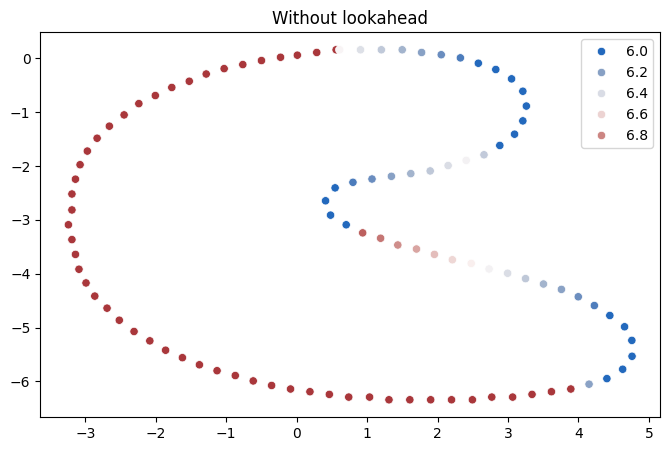

In [87]:

fig, ax = plt.subplots(figsize=(8, 5))
ax = sns.scatterplot(x=x, y=y, hue=velocity_no_lookahead,
                     palette="vlag").set_title("Without lookahead")


# Calculate distance and optimal time between each racing point


In [76]:

distance_to_prev = []
for i in range(len(racing_track)):
    indexes = circle_indexes(racing_track, i, add_index_1=-1, add_index_2=0)[0:2]
    coords = [racing_track[indexes[0]],racing_track[indexes[1]]]
    dist_to_prev = dist_2_points(x1=coords[0][0], x2=coords[1][0], y1=coords[0][1], y2=coords[1][1])
    distance_to_prev.append(dist_to_prev)
    
time_to_prev = [(distance_to_prev[i]/velocity[i]) for i in range(len(racing_track))]

total_time = sum(time_to_prev)
print(f"Total time for track, if racing line and speeds are followed perfectly: {total_time} s")


Total time for track, if racing line and speeds are followed perfectly: 4.202539504755173 s



# Append everything together and save to .txt file

In [77]:


# Now we have list with columns (x,y,speed,distance,time)
racing_track_everything = []
for i in range(len(racing_track)):
    racing_track_everything.append([racing_track[i][0],
                                    racing_track[i][1],
                                    velocity[i],
                                    time_to_prev[i]])
# Round to 5 decimals
racing_track_everything = np.around(racing_track_everything, 5).tolist()



In [78]:


# Write to txt file
with open(f'optimals_newest_{TRACK_NAME}.txt', 'w') as f:
    f.write("[")
    for line in racing_track_everything:
        f.write("%s" % line)
        if line != racing_track_everything[-1]:
            f.write(",\n")
    f.write("]")



NameError: name 'TRACK_NAME' is not defined